In [1]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import load

In [2]:
def get_median_and_iqr(pregret_list):
    median = np.median(pregret_list, axis=0)
    q1 = np.percentile(pregret_list, 25, axis=0)
    q3 = np.percentile(pregret_list, 75, axis=0)
    return median, q1, q3


def get_mean_and_ci(pregret_list):
    avg = np.mean(pregret_list, axis=0)
    lower_bound = np.percentile(pregret_list, 2.5, axis=0)
    upper_bound = np.percentile(pregret_list, 97.5, axis=0)
    return avg, lower_bound, upper_bound


def plot_curve(ax, filename, name, color, remove_warmup=False):
    results = load(f"../data/{filename}.joblib")
    pregrets, times = np.array(results["pregrets"]), np.array(results["times"])
    if remove_warmup:
        pregrets, times = pregrets[:, times >= 200], times[times >= 200]
    median, q1, q3 = get_median_and_iqr(pregrets)
    ax.plot(times, median, label=name, lw=lw, color=color)
    ax.fill_between(times, q1, q3, alpha=0.2, color=color)

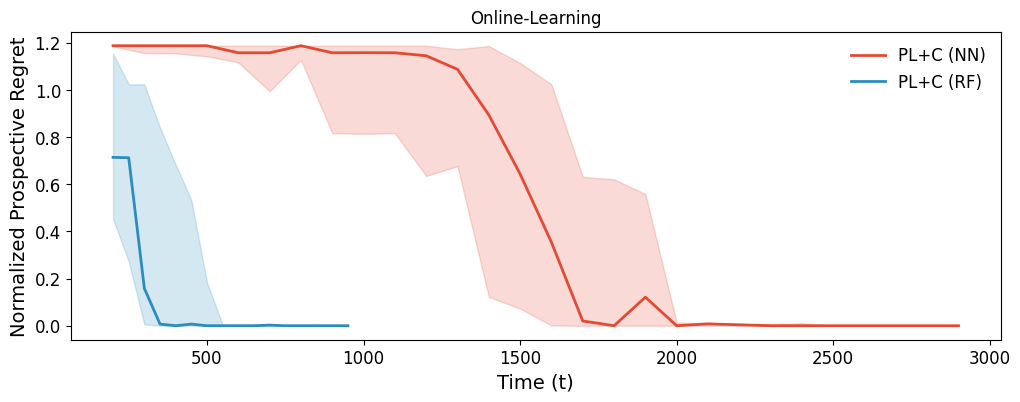

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
lw = 2
fontsize = 14

color = "#e34a33"
results = load("../data/results_plc_nn.joblib")
pregrets, times = results["pregrets"], results["times"]
median, q1, q3 = get_median_and_iqr(pregrets)
ax.plot(times, median, label="PL+C (NN)", lw=lw, color=color)
ax.fill_between(times, q1, q3, alpha=0.2, color=color)

color = "#2b8cbe"
results = load("../data/results_plc_rf.joblib")
pregrets, times = results["pregrets"], results["times"]
median, q1, q3 = get_median_and_iqr(pregrets)
ax.plot(times, median, label="PL+C (RF)", lw=lw, color=color)
ax.fill_between(times, q1, q3, alpha=0.2, color=color)

ax.set_xlabel("Time (t)", fontsize=fontsize)
ax.set_ylabel("Normalized Prospective Regret", fontsize=fontsize)
ax.tick_params(axis="both", which="major", labelsize=fontsize - 2)
ax.legend(fontsize=fontsize - 2, frameon=False)
ax.set_title("Online-Learning")
plt.show()

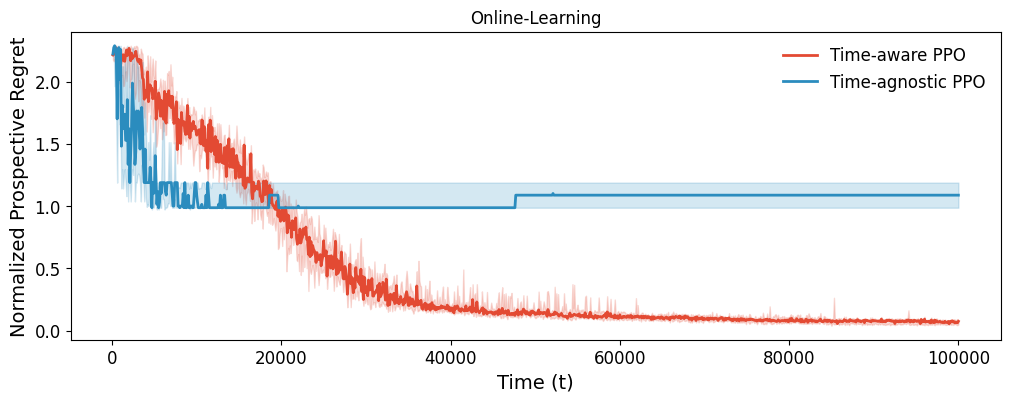

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
lw = 2
fontsize = 14

color = "#e34a33"
results = load("../data/results_ppo_time.joblib")
pregrets, times = results["pregrets"], results["times"]
median, q1, q3 = get_median_and_iqr(pregrets)
ax.plot(times, median, label="Time-aware PPO", lw=lw, color=color)
ax.fill_between(times, q1, q3, alpha=0.2, color=color)

color = "#2b8cbe"
results = load("../data/results_ppo_notime.joblib")
pregrets, times = results["pregrets"], results["times"]
median, q1, q3 = get_median_and_iqr(pregrets)
ax.plot(times, median, label="Time-agnostic PPO", lw=lw, color=color)
ax.fill_between(times, q1, q3, alpha=0.2, color=color)

ax.set_xlabel("Time (t)", fontsize=fontsize)
ax.set_ylabel("Normalized Prospective Regret", fontsize=fontsize)
ax.tick_params(axis="both", which="major", labelsize=fontsize - 2)
ax.legend(fontsize=fontsize - 2, frameon=False)
ax.set_title("Online-Learning")
plt.show()

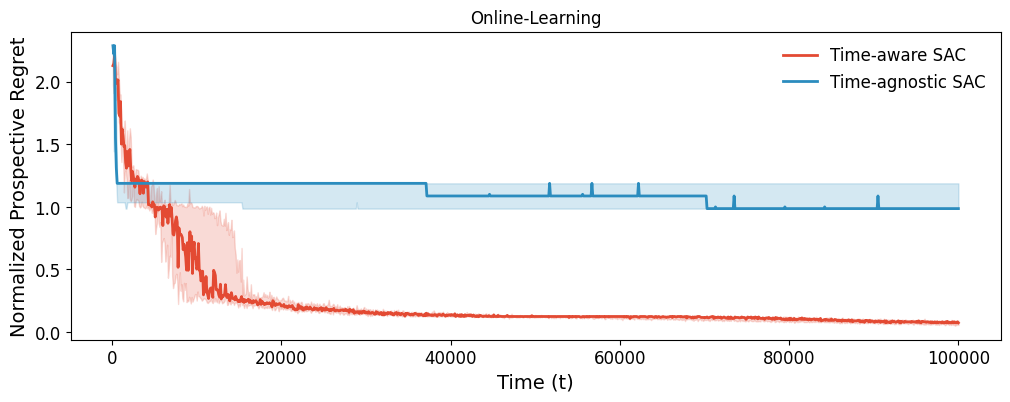

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
lw = 2
fontsize = 14

color = "#e34a33"
results = load("../data/results_sac_time.joblib")
pregrets, times = results["pregrets"], results["times"]
median, q1, q3 = get_median_and_iqr(pregrets)
ax.plot(times, median, label="Time-aware SAC", lw=lw, color=color)
ax.fill_between(times, q1, q3, alpha=0.2, color=color)

color = "#2b8cbe"
results = load("../data/results_sac_notime.joblib")
pregrets, times = results["pregrets"], results["times"]
median, q1, q3 = get_median_and_iqr(pregrets)
ax.plot(times, median, label="Time-agnostic SAC", lw=lw, color=color)
ax.fill_between(times, q1, q3, alpha=0.2, color=color)

ax.set_xlabel("Time (t)", fontsize=fontsize)
ax.set_ylabel("Normalized Prospective Regret", fontsize=fontsize)
ax.tick_params(axis="both", which="major", labelsize=fontsize - 2)
ax.legend(fontsize=fontsize - 2, frameon=False)
ax.set_title("Online-Learning")
plt.show()

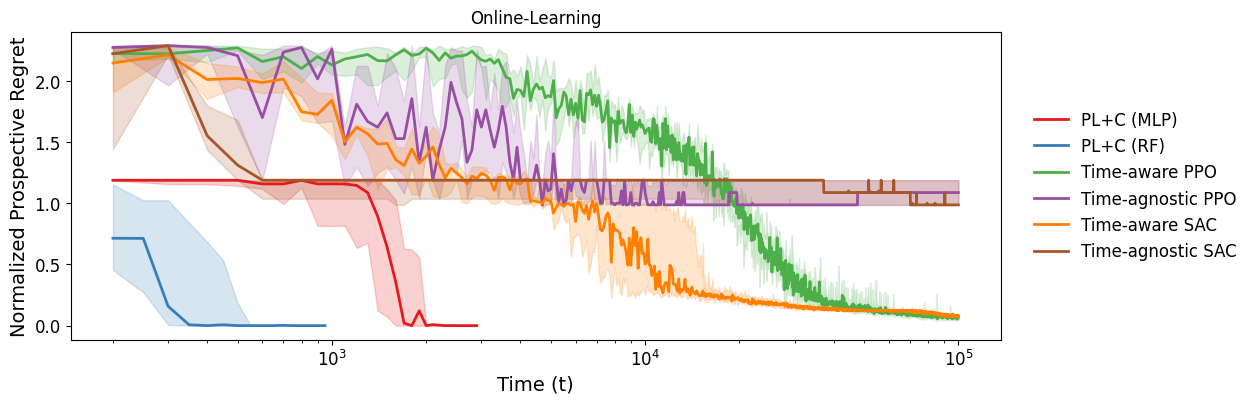

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
lw = 2
fontsize = 14

plot_curve(ax, "results_plc_nn", "PL+C (MLP)", "#e41a1c")
plot_curve(ax, "results_plc_rf", "PL+C (RF)", "#377eb8")
plot_curve(ax, "results_ppo_time", "Time-aware PPO", "#4daf4a", remove_warmup=True)
plot_curve(ax, "results_ppo_notime", "Time-agnostic PPO", "#984ea3", remove_warmup=True)
plot_curve(ax, "results_sac_time", "Time-aware SAC", "#ff7f00", remove_warmup=True)
plot_curve(ax, "results_sac_notime", "Time-agnostic SAC", "#a65628", remove_warmup=True)

ax.set_xlabel("Time (t)", fontsize=fontsize)
ax.set_ylabel("Normalized Prospective Regret", fontsize=fontsize)
ax.set_xscale("log")
ax.tick_params(axis="both", which="major", labelsize=fontsize - 2)
ax.legend(
    fontsize=fontsize - 2, frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5)
)
ax.set_title("Online-Learning")
plt.show()